<a href="https://colab.research.google.com/github/medistlabo/TCGA_Practice/blob/main/tcga_practice_day13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "patient": ["P1","P2","P3","P4","P5","P6","P7","P8","P9","P10"],
    "expression": [5,12,18,25,30,7,40,22,15,35],
    "survival_month": [50,40,35,20,15,45,10,25,38,12],
    "status": [0,0,1,1,1,0,1,1,0,1]
}

df = pd.DataFrame(data)

df

,patient,expression,survival_month,status
0,P1,5,50,0
1,P2,12,40,0
2,P3,18,35,1
3,P4,25,20,1
4,P5,30,15,1
5,P6,7,45,0
6,P7,40,10,1
7,P8,22,25,1
8,P9,15,38,0
9,P10,35,12,1


In [11]:
df["group_median"] = df["expression"].apply(
    lambda x: "High"
      if x>= df["expression"].median()
     else "Low"
)

df

,patient,expression,survival_month,status,group_median
0,P1,5,50,0,Low
1,P2,12,40,0,Low
2,P3,18,35,1,Low
3,P4,25,20,1,High
4,P5,30,15,1,High
5,P6,7,45,0,Low
6,P7,40,10,1,High
7,P8,22,25,1,High
8,P9,15,38,0,Low
9,P10,35,12,1,High


In [22]:
df.groupby("group_median")["status"].mean()

,status
group_median,
High,1.0
Low,0.2


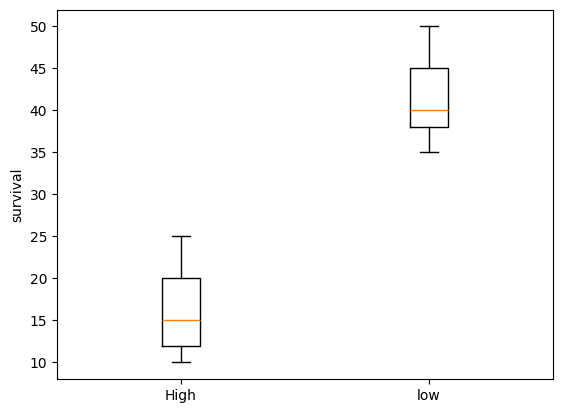

In [19]:
high_median_survival = df[df["group_median"] == "High"]["survival_month"]
low_median_survival = df[df["group_median"] == "Low"]["survival_month"]

plt.boxplot([high_median_survival, low_median_survival])
plt.xticks([1, 2], ["High", "low"])
plt.ylabel("survival")

plt.show()

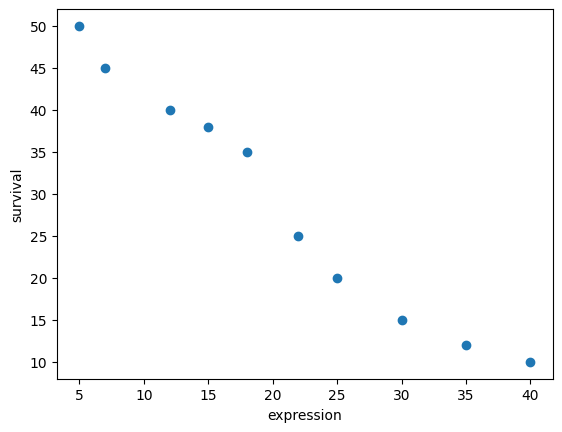

In [23]:
plt.scatter(df["expression"], df["survival_month"])

plt.xlabel("expression")
plt.ylabel("survival")

plt.show()